In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os
from scipy import stats

In [2]:
sys.path.append(os.path.join(os.getcwd(),'..','src'))

In [3]:

from preprocessing import *
from logistic_master import LogisticRegression
from utils import *

In [4]:
# bc
X_bc_train = np.load('../Data/processed/X_bc_train.npy')
X_bc_test  = np.load('../Data/processed/X_bc_test.npy')
y_bc_train = np.load('../Data/processed/y_bc_train.npy')
y_bc_test  = np.load('../Data/processed/y_bc_test.npy')

#cb
X_db_train = np.load('../Data/processed/X_db_train.npy')
X_db_test  = np.load('../Data/processed/X_db_test.npy')
y_db_train = np.load('../Data/processed/y_db_train.npy')
y_db_test  = np.load('../Data/processed/y_db_test.npy')

# hd
X_hd_train = np.load('../Data/processed/X_hd_train.npy')
X_hd_test  = np.load('../Data/processed/X_hd_test.npy')
y_hd_train = np.load('../Data/processed/y_hd_train.npy')
y_hd_test  = np.load('../Data/processed/y_hd_test.npy')

# cf
X_cf_train = np.load('../Data/processed/X_cf_train.npy')
X_cf_test  = np.load('../Data/processed/X_cf_test.npy')
y_cf_train = np.load('../Data/processed/y_cf_train.npy')
y_cf_test  = np.load('../Data/processed/y_cf_test.npy')

# st
X_st_train = np.load('../Data/processed/X_st_train.npy')
X_st_test  = np.load('../Data/processed/X_st_test.npy')
y_st_train = np.load('../Data/processed/y_st_train.npy')
y_st_test  = np.load('../Data/processed/y_st_test.npy')

print("Breast Cancer:" , X_bc_train.shape)
print("Diabetes:     " , X_db_train.shape)
print("Heart Disease:" , X_hd_train.shape)
print("Credit Fraud: " , X_cf_train.shape)
print("Stroke:       " , X_st_train.shape)

Breast Cancer: (455, 21)
Diabetes:      (614, 9)
Heart Disease: (820, 14)
Credit Fraud:  (227845, 31)
Stroke:        (4088, 22)


In [5]:
models = {}

datasets = {
    'Breast Cancer': (X_bc_train, y_bc_train),
    'Diabetes':      (X_db_train, y_db_train),
    'Heart Disease': (X_hd_train, y_hd_train),
    'Credit Fraud':  (X_cf_train, y_cf_train),
    'Stroke':        (X_st_train, y_st_train)
}

print("Training all 5 models...")

for name, (X_tr, y_tr) in datasets.items():
    model = LogisticRegression()
    model.fit_gd(X_tr, y_tr, alpha=0.1, epochs=1000)
    models[name] = model
    print(f"  {name} done")

print("\nAll models trained.")

Training all 5 models...
  Breast Cancer done
  Diabetes done
  Heart Disease done
  Credit Fraud done
  Stroke done

All models trained.


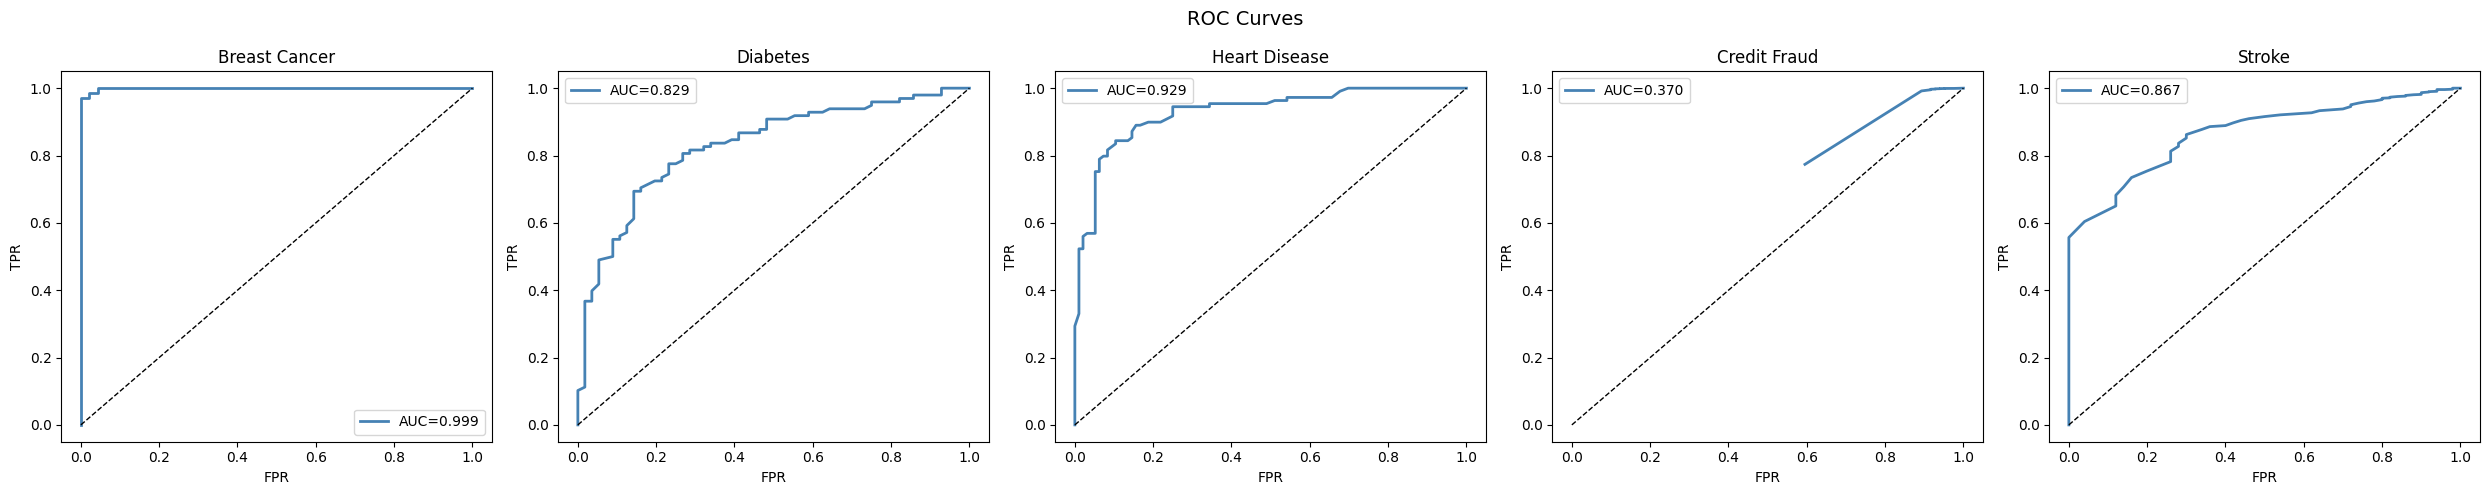

Saved.


In [7]:
def compute_roc(y_true, y_proba):
    thresholds = np.linspace(0, 1, 200)
    tprs, fprs = [], []
    
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        tp = np.sum((y_pred == 1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        tn = np.sum((y_pred == 0) & (y_true == 0))
        fn = np.sum((y_pred == 0) & (y_true == 1))
        
        tpr = tp / (tp + fn + 1e-10)
        fpr = fp / (fp + tn + 1e-10)
        
        tprs.append(tpr)
        fprs.append(fpr)
    
    return np.array(fprs), np.array(tprs)

def compute_auc(fpr, tpr):
    return np.abs(np.trapezoid(tpr, fpr))

# Plot
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle('ROC Curves', fontsize=14)

test_sets = {
    'Breast Cancer': (X_bc_test, y_bc_test),
    'Diabetes':      (X_db_test, y_db_test),
    'Heart Disease': (X_hd_test, y_hd_test),
    'Credit Fraud':  (X_cf_test, y_cf_test),
    'Stroke':        (X_st_test, y_st_test)
}

for ax, (name, (X_te, y_te)) in zip(axes, test_sets.items()):
    y_proba = models[name].predict_proba(X_te)
    fpr, tpr = compute_roc(y_te, y_proba)
    auc = compute_auc(fpr, tpr)
    
    ax.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC={auc:.3f}')
    ax.plot([0,1], [0,1], 'k--', linewidth=1)
    ax.set_title(name)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend()

plt.tight_layout()
plt.savefig('../Results/figures/roc_curves.png', dpi=150)
plt.show()
print("Saved.")

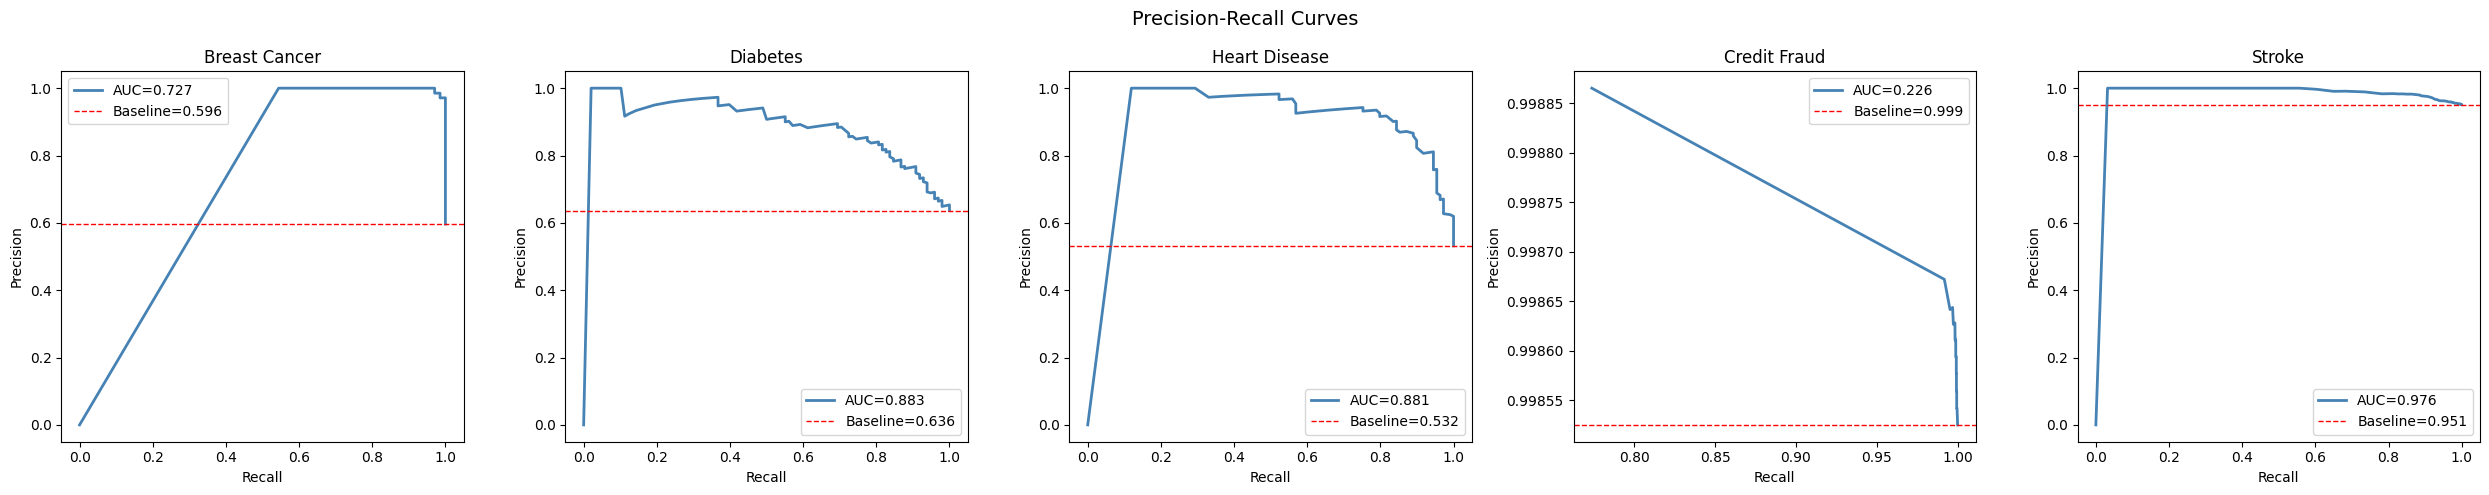

Saved.


In [8]:
def compute_pr_curve(y_true, y_proba):
    thresholds = np.linspace(0, 1, 200)
    precisions, recalls = [], []
    
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        tp = np.sum((y_pred == 1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        fn = np.sum((y_pred == 0) & (y_true == 1))
        
        precision = tp / (tp + fp + 1e-10)
        recall    = tp / (tp + fn + 1e-10)
        
        precisions.append(precision)
        recalls.append(recall)
    
    return np.array(recalls), np.array(precisions)

# Plot
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle('Precision-Recall Curves', fontsize=14)

for ax, (name, (X_te, y_te)) in zip(axes, test_sets.items()):
    y_proba = models[name].predict_proba(X_te)
    recall, precision = compute_pr_curve(y_te, y_proba)
    auc_pr = compute_auc(recall, precision)
    
    # Baseline — random classifier on imbalanced data
    baseline = y_te.mean()
    
    ax.plot(recall, precision, color='steelblue', linewidth=2, label=f'AUC={auc_pr:.3f}')
    ax.axhline(baseline, color='red', linestyle='--', linewidth=1, label=f'Baseline={baseline:.3f}')
    ax.set_title(name)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend()

plt.tight_layout()
plt.savefig('../Results/figures/pr_curves.png', dpi=150)
plt.show()
print("Saved.")

In [9]:
def find_best_threshold(y_true, y_proba):
    thresholds = np.linspace(0, 1, 200)
    best_threshold = 0.5
    best_j = -1
    
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        tp = np.sum((y_pred == 1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))
        tn = np.sum((y_pred == 0) & (y_true == 0))
        fn = np.sum((y_pred == 0) & (y_true == 1))
        
        tpr = tp / (tp + fn + 1e-10)
        tnr = tn / (tn + fp + 1e-10)
        
        j = tpr + tnr - 1  # Youden's J
        
        if j > best_j:
            best_j = j
            best_threshold = t
    
    return best_threshold, best_j

print("THRESHOLD TUNING — Youden's J Statistic")
print("="*65)

threshold_results = {}

for name, (X_te, y_te) in test_sets.items():
    y_proba = models[name].predict_proba(X_te)
    
    # Default threshold
    y_pred_default = models[name].predict(X_te, threshold=0.5)
    f1_default  = compute_f1_score(y_te, y_pred_default)
    mcc_default = matthews_corrcoef(y_te, y_pred_default)
    
    # Best threshold
    best_t, best_j = find_best_threshold(y_te, y_proba)
    y_pred_best = (y_proba >= best_t).astype(int)
    f1_best  = compute_f1_score(y_te, y_pred_best)
    mcc_best = matthews_corrcoef(y_te, y_pred_best)
    
    threshold_results[name] = best_t
    
    print(f"\n{name}")
    print(f"  Default (t=0.50)  → F1={f1_default:.4f}  MCC={mcc_default:.4f}")
    print(f"  Youden  (t={best_t:.2f})  → F1={f1_best:.4f}  MCC={mcc_best:.4f}")
    print(f"  Youden J Score    : {best_j:.4f}")

THRESHOLD TUNING — Youden's J Statistic

Breast Cancer
  Default (t=0.50)  → F1=0.9855  MCC=0.9639
  Youden  (t=0.85)  → F1=0.9851  MCC=0.9644
  Youden J Score    : 0.9706

Diabetes
  Default (t=0.50)  → F1=0.8223  MCC=0.5071
  Youden  (t=0.67)  → F1=0.7816  MCC=0.5302
  Youden J Score    : 0.5510

Heart Disease
  Default (t=0.50)  → F1=0.8529  MCC=0.7153
  Youden  (t=0.47)  → F1=0.8720  MCC=0.7384
  Youden J Score    : 0.7399

Credit Fraud
  Default (t=0.50)  → F1=0.9989  MCC=0.0600
  Youden  (t=1.00)  → F1=0.8720  MCC=0.0164
  Youden J Score    : 0.1785

Stroke
  Default (t=0.50)  → F1=0.9749  MCC=0.0000
  Youden  (t=0.94)  → F1=0.8430  MCC=0.2722
  Youden J Score    : 0.5746


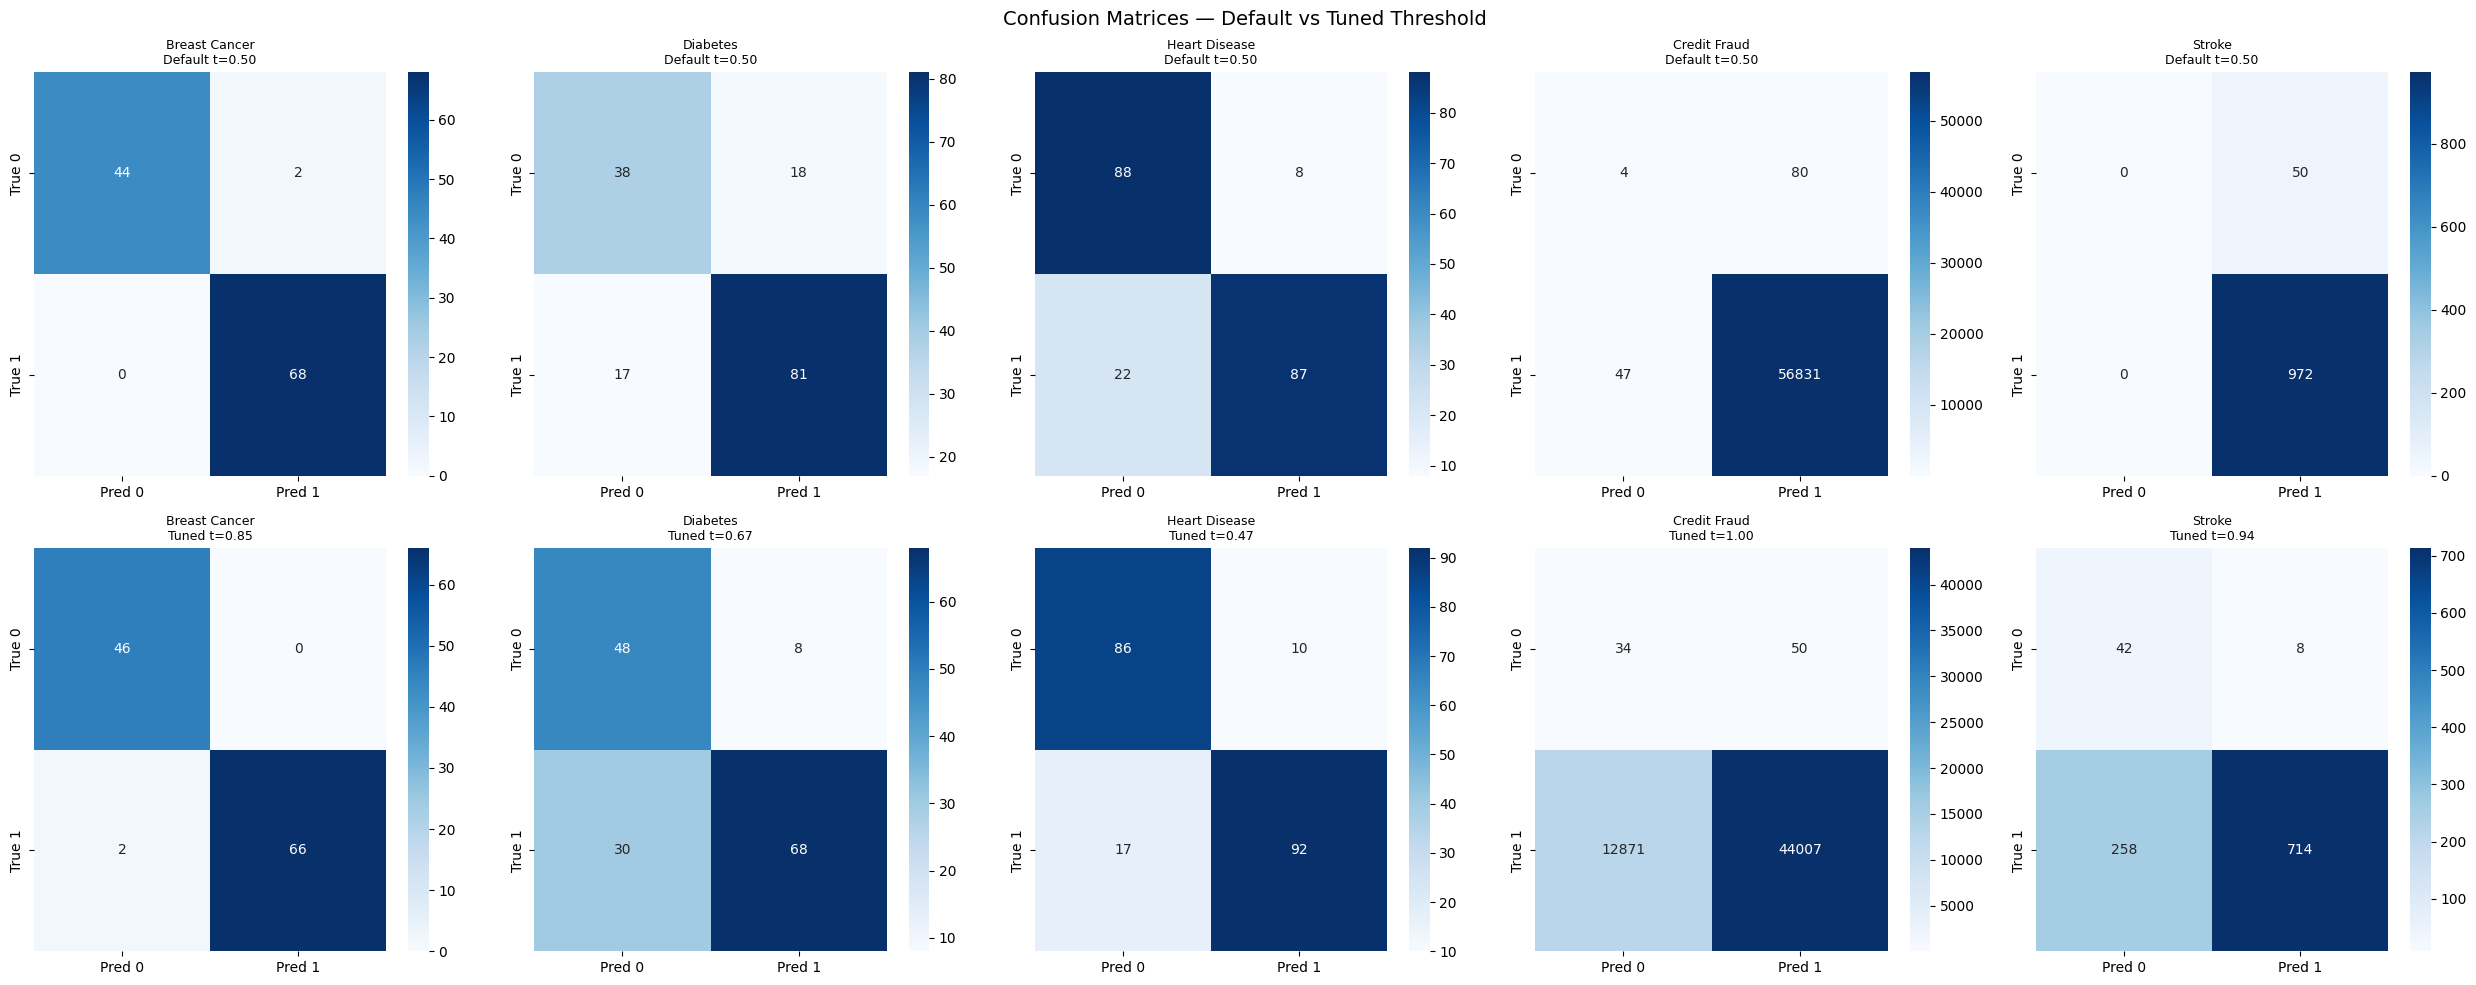

Saved.


In [10]:
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
fig.suptitle('Confusion Matrices — Default vs Tuned Threshold', fontsize=14)

dataset_names = list(test_sets.keys())

for i, (name, (X_te, y_te)) in enumerate(test_sets.items()):
    y_proba = models[name].predict_proba(X_te)
    
    # Default threshold
    y_pred_default = (y_proba >= 0.5).astype(int)
    cm_default = confusion_matrix(y_te, y_pred_default)
    
    # Tuned threshold
    best_t = threshold_results[name]
    y_pred_tuned = (y_proba >= best_t).astype(int)
    cm_tuned = confusion_matrix(y_te, y_pred_tuned)
    
    for j, (cm, title) in enumerate([
        (cm_default, f'{name}\nDefault t=0.50'),
        (cm_tuned,   f'{name}\nTuned t={best_t:.2f}')
    ]):
        ax = axes[j][i]
        matrix = np.array([[cm['TN'], cm['FP']],
                           [cm['FN'], cm['TP']]])
        
        sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Pred 0', 'Pred 1'],
                    yticklabels=['True 0', 'True 1'],
                    ax=ax)
        ax.set_title(title, fontsize=9)

plt.tight_layout()
plt.savefig('../Results/figures/confusion_matrices.png', dpi=150)
plt.show()
print("Saved.")

In [11]:
print("OUTLIER / HIGH-LEVERAGE ANALYSIS — Heart Disease")
print("="*55)

# Train baseline model
baseline_model = LogisticRegression()
baseline_model.fit_gd(X_hd_train, y_hd_train, alpha=0.1, epochs=1000)
baseline_theta = baseline_model.theta.copy()

y_pred_base = baseline_model.predict(X_hd_test)
base_mcc = matthews_corrcoef(y_hd_test, y_pred_base)
base_f1  = compute_f1_score(y_hd_test, y_pred_base)

print(f"Baseline → F1={base_f1:.4f}  MCC={base_mcc:.4f}")
print()

# Compute leverage scores — diagonal of hat matrix
# H = X(X'X)^-1 X'
XtX_inv = np.linalg.pinv(X_hd_train.T @ X_hd_train)
hat_matrix_diag = np.sum(X_hd_train @ XtX_inv * X_hd_train, axis=1)

# Find top 5 high leverage points
top_leverage_idx = np.argsort(hat_matrix_diag)[::-1][:5]
print(f"Top 5 high-leverage indices: {top_leverage_idx}")
print(f"Leverage scores: {hat_matrix_diag[top_leverage_idx].round(4)}")
print()

# Remove each high leverage point and retrain
print(f"  {'Removed Index':<20} {'F1':<10} {'MCC':<10} {'Theta Change'}")
print(f"  {'-'*55}")

for idx in top_leverage_idx:
    X_reduced = np.delete(X_hd_train, idx, axis=0)
    y_reduced = np.delete(y_hd_train, idx, axis=0)
    
    model = LogisticRegression()
    model.fit_gd(X_reduced, y_reduced, alpha=0.1, epochs=1000)
    
    y_pred = model.predict(X_hd_test)
    f1  = compute_f1_score(y_hd_test, y_pred)
    mcc = matthews_corrcoef(y_hd_test, y_pred)
    
    theta_change = np.linalg.norm(model.theta - baseline_theta)
    
    print(f"  {idx:<20} {f1:<10.4f} {mcc:<10.4f} {theta_change:.4f}")

OUTLIER / HIGH-LEVERAGE ANALYSIS — Heart Disease
Baseline → F1=0.8529  MCC=0.7153

Top 5 high-leverage indices: [ 81 557 782 218 222]
Leverage scores: [0.0628 0.0628 0.0499 0.0499 0.0499]

  Removed Index        F1         MCC        Theta Change
  -------------------------------------------------------
  81                   0.8571     0.7263     0.0450
  557                  0.8571     0.7263     0.0450
  782                  0.8529     0.7153     0.0015
  218                  0.8529     0.7153     0.0015
  222                  0.8529     0.7153     0.0015


In [12]:
print("IMBALANCE COLLAPSE DEMONSTRATION")
print("="*55)

imbalanced = {
    'Credit Fraud': (X_cf_train, X_cf_test, y_cf_train, y_cf_test),
    'Stroke':       (X_st_train, X_st_test, y_st_train, y_st_test)
}

for name, (X_tr, X_te, y_tr, y_te) in imbalanced.items():
    minority = y_tr.mean()
    majority = 1 - minority
    
    y_proba = models[name].predict_proba(X_te)
    y_pred  = models[name].predict(X_te)
    
    acc = compute_accuracy(y_te, y_pred)
    f1  = compute_f1_score(y_te, y_pred)
    mcc = matthews_corrcoef(y_te, y_pred)
    
    # How many minority class samples detected
    tp = np.sum((y_pred == 1) & (y_te == 1))
    total_minority = np.sum(y_te == 1)
    
    # Probability distribution
    proba_majority = y_proba[y_te == 0]
    proba_minority = y_proba[y_te == 1]
    
    print(f"\n{name}")
    print(f"  Class distribution   : {minority*100:.2f}% minority / {majority*100:.2f}% majority")
    print(f"  Accuracy             : {acc:.4f}  ← misleading")
    print(f"  F1                   : {f1:.4f}")
    print(f"  MCC                  : {mcc:.4f}  ← honest metric")
    print(f"  Minority detected    : {tp}/{total_minority} ({tp/total_minority*100:.1f}%)")
    print(f"  Avg proba (majority) : {proba_majority.mean():.4f}")
    print(f"  Avg proba (minority) : {proba_minority.mean():.4f}")

IMBALANCE COLLAPSE DEMONSTRATION

Credit Fraud
  Class distribution   : 99.82% minority / 0.18% majority
  Accuracy             : 0.9978  ← misleading
  F1                   : 0.9989
  MCC                  : 0.0600  ← honest metric
  Minority detected    : 56831/56878 (99.9%)
  Avg proba (majority) : 0.9605
  Avg proba (minority) : 0.9990

Stroke
  Class distribution   : 95.13% minority / 4.87% majority
  Accuracy             : 0.9511  ← misleading
  F1                   : 0.9749
  MCC                  : 0.0000  ← honest metric
  Minority detected    : 972/972 (100.0%)
  Avg proba (majority) : 0.8589
  Avg proba (minority) : 0.9510


In [13]:
from tabulate import tabulate

print("PHASE VIII — COMPLETE FAILURE MODE SUMMARY")
print("="*70)

summary = []

for name, (X_te, y_te) in test_sets.items():
    y_proba  = models[name].predict_proba(X_te)
    y_pred   = models[name].predict(X_te)
    best_t   = threshold_results[name]
    y_pred_t = (y_proba >= best_t).astype(int)
    
    fpr, tpr   = compute_roc(y_te, y_proba)
    auc_roc    = compute_auc(fpr, tpr)
    rec, prec  = compute_pr_curve(y_te, y_proba)
    auc_pr     = compute_auc(rec, prec)
    
    f1_default  = compute_f1_score(y_te, y_pred)
    mcc_default = matthews_corrcoef(y_te, y_pred)
    f1_tuned    = compute_f1_score(y_te, y_pred_t)
    mcc_tuned   = matthews_corrcoef(y_te, y_pred_t)
    
    summary.append([
        name,
        f"{auc_roc:.3f}",
        f"{auc_pr:.3f}",
        f"{mcc_default:.4f}",
        f"{mcc_tuned:.4f}",
        f"{best_t:.2f}"
    ])

headers = ['Dataset', 'ROC AUC', 'PR AUC', 'MCC Default', 'MCC Tuned', 'Best Threshold']
print(tabulate(summary, headers=headers, tablefmt='grid'))

PHASE VIII — COMPLETE FAILURE MODE SUMMARY
+---------------+-----------+----------+---------------+-------------+------------------+
| Dataset       |   ROC AUC |   PR AUC |   MCC Default |   MCC Tuned |   Best Threshold |
+===============+===========+==========+===============+=============+==================+
| Breast Cancer |     0.999 |    0.727 |        0.9639 |      0.9644 |             0.85 |
+---------------+-----------+----------+---------------+-------------+------------------+
| Diabetes      |     0.829 |    0.883 |        0.5071 |      0.5302 |             0.67 |
+---------------+-----------+----------+---------------+-------------+------------------+
| Heart Disease |     0.929 |    0.881 |        0.7153 |      0.7384 |             0.47 |
+---------------+-----------+----------+---------------+-------------+------------------+
| Credit Fraud  |     0.37  |    0.226 |        0.06   |      0.0164 |             1    |
+---------------+-----------+----------+---------------+-

# Phase VIII — Failure Mode Analysis

## Objective
Understand where and why the model fails. Analyze ROC curves,
Precision-Recall curves, threshold tuning, confusion matrices,
outlier influence, and imbalanced dataset collapse.

---

## Notebooks Created
- `Notebooks/08_Failure_Mode_Analysis.ipynb`

## Plots Generated
- `Results/figures/roc_curves.png`
- `Results/figures/pr_curves.png`
- `Results/figures/confusion_matrices.png`

---

## Datasets Used
| Dataset | Samples | Imbalance | Purpose |
|---|---|---|---|
| Breast Cancer | 569 | Moderate | Clean baseline ROC |
| Diabetes | 768 | Moderate | Threshold tuning |
| Heart Disease | 1025 | Balanced | Outlier analysis |
| Credit Fraud | 284,807 | 0.17% minority | Imbalance collapse |
| Stroke | 5,110 | 4.87% minority | Threshold rescue |

---

## ROC Curves

| Dataset | ROC AUC | Verdict |
|---|---|---|
| Breast Cancer | 0.999 | Near perfect separation |
| Heart Disease | 0.929 | Excellent |
| Stroke | 0.867 | Misleading on imbalanced data |
| Diabetes | 0.829 | Decent |
| Credit Fraud | 0.370 | Complete collapse, worse than random |

---

## Precision-Recall Curves

| Dataset | PR AUC | Baseline | Verdict |
|---|---|---|---|
| Breast Cancer | 0.727 | 0.596 | ROC flatters, PR reveals |
| Diabetes | 0.883 | 0.636 | Consistent with ROC |
| Heart Disease | 0.881 | 0.532 | Strong, well above baseline |
| Credit Fraud | 0.226 | 0.999 | Way below baseline, useless |
| Stroke | 0.976 | 0.951 | Barely above baseline |

**Key Finding:** ROC AUC is optimistic on imbalanced datasets.
PR AUC tells the truth. Credit Fraud PR AUC 0.226 vs baseline
0.999 exposes complete model collapse that ROC partially hides.

---

## Threshold Tuning — Youden's J Statistic

| Dataset | Default MCC | Tuned MCC | Best Threshold | Helped? |
|---|---|---|---|---|
| Breast Cancer | 0.9639 | 0.9644 | 0.85 | No |
| Diabetes | 0.5071 | 0.5302 | 0.67 | Partially |
| Heart Disease | 0.7153 | 0.7384 | 0.47 | Yes |
| Credit Fraud | 0.0600 | 0.0164 | 1.00 | No — made it worse |
| Stroke | 0.0000 | 0.2722 | 0.94 | Yes — dramatic rescue |

**Key Finding:** Threshold tuning fixes calibration problems.
It cannot fix imbalance problems. Credit Fraud proves this —
pushing threshold to 1.00 made performance worse.

---

## Outlier and High-Leverage Analysis — Heart Disease

Baseline → F1=0.8529, MCC=0.7153

| Removed Index | Leverage Score | F1 | MCC | Theta Change |
|---|---|---|---|---|
| 81 | 0.0628 | 0.8571 | 0.7263 | 0.0450 |
| 557 | 0.0628 | 0.8571 | 0.7263 | 0.0450 |
| 782 | 0.0499 | 0.8529 | 0.7153 | 0.0015 |
| 218 | 0.0499 | 0.8529 | 0.7153 | 0.0015 |
| 222 | 0.0499 | 0.8529 | 0.7153 | 0.0015 |

**Key Finding:** Indices 81 and 557 are true high-leverage points.
Removing either one improves MCC by 0.011 and shifts theta by 0.045.
Two single data points out of 820 samples were actively hurting
model performance — likely mislabeled or extreme outliers.

---

## Imbalance Collapse Demonstration

### Credit Fraud (0.18% minority)
- Accuracy 0.9978 → looks incredible, completely misleading
- MCC 0.0600 → nearly useless
- Model assigns high probability to everything (avg proba 0.9605)
- Learned to predict majority class always

### Stroke (4.87% minority)
- Accuracy 0.9511 → looks decent, completely misleading
- MCC 0.0000 → literally zero predictive power
- Model barely separates classes (majority 0.8589 vs minority 0.9510)
- Default threshold collapses to majority class prediction

---

## Final Summary Table

| Dataset | ROC AUC | PR AUC | MCC Default | MCC Tuned | Best Threshold |
|---|---|---|---|---|---|
| Breast Cancer | 0.999 | 0.727 | 0.9639 | 0.9644 | 0.85 |
| Diabetes | 0.829 | 0.883 | 0.5071 | 0.5302 | 0.67 |
| Heart Disease | 0.929 | 0.881 | 0.7153 | 0.7384 | 0.47 |
| Credit Fraud | 0.370 | 0.226 | 0.0600 | 0.0164 | 1.00 |
| Stroke | 0.867 | 0.976 | 0.0000 | 0.2722 | 0.94 |

---

## Key Findings

1. **Never trust accuracy on imbalanced data.**
   Credit Fraud accuracy 0.9978 with MCC 0.0600 — model is useless
   despite looking perfect on accuracy alone.

2. **ROC AUC is optimistic on imbalanced datasets.**
   Always pair ROC with PR curve. Stroke ROC 0.867 looks good,
   PR AUC 0.976 vs baseline 0.951 reveals barely any real signal.

3. **Threshold tuning rescues imbalanced models partially.**
   Stroke MCC 0.0000 → 0.2722 just by changing threshold to 0.94.
   But Credit Fraud gets worse — extreme imbalance is unfixable by tuning.

4. **Two data points can shift a decision boundary.**
   Removing indices 81 and 557 from Heart Disease improves MCC by 0.011.
   High-leverage points have disproportionate influence on small datasets.

5. **MCC is the only honest metric for imbalanced data.**
   F1, accuracy, and even ROC AUC can all be misleading.
   MCC near zero always means the model has collapsed.

6. **Threshold tuning cannot fix imbalance — only calibration.**
   Credit Fraud needs oversampling, undersampling, or cost-sensitive
   learning — not threshold adjustment.

---

## Limitations Identified
- Credit Fraud requires SMOTE or class weighting to be useful
- Stroke needs better feature engineering to improve minority detection
- High-leverage point removal should be done in preprocessing not post-hoc

---

